# Cohort FACTM — synthetic experiments
Validate inter-cohort variability detection on synthetic data. Hungarian
matching aligns estimated and true factors before metrics.
- Exp 0 — Null test: no cohort differences; gamma must stay near the prior pi.
- Exp 1 — Single active factor: one asymmetric cohort offset; signal localization.
- Exp 2 — Full cohort profiles: C=4 distinct mean vectors; E[gamma*delta] rows vs true mu.
- Exp 3 — Cohort distance structure: pairwise L2 distances preserved in latent space.
- Exp 4 — Signal scale: larger mu => better distance recovery.

### Imports

In [1]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

from src import FACTModel
from src.enums import Likelihood, WPrior, ZPrior
from src.model_config import CohortPriorConfig, ModelConfig, SimpleViewConfig
from src.views import Views

### Helpers: data generation, model fitting, Hungarian matching

In [2]:
def generate_data(mu_ck, sigma, n_per_cohort, dims=(15, 15), noise=1.0, seed=0):
    """Generate synthetic cohort data: Z ~ N(mu_ck[c], sigma), Y_m = Z W_m^T + noise."""
    rng = np.random.default_rng(seed)
    C, K = mu_ck.shape
    codes = np.repeat(np.arange(C), n_per_cohort)
    Z = np.array([rng.normal(mu_ck[c], sigma) for c in codes])
    Ys = [Z @ rng.normal(size=(d, K)).T + rng.normal(scale=noise, size=(Z.shape[0], d)) for d in dims]
    return Views.from_list(Ys, cohorts=np.array([f'c{c}' for c in codes])), Z, codes


def fit_cohort(views, K, pi=0.5, max_iter=100, seed=0):
    """Fit CohortFACTM with spike-and-slab cohort prior (ZPrior.COHORT)."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.COHORT] * K,
        cohort_prior_config=CohortPriorConfig(pi=pi),
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def fit_baseline(views, K, max_iter=100, seed=0):
    """Fit standard FACTM with isotropic N(0,1) prior — no cohort structure."""
    cfg = ModelConfig(
        simple_view_configs=[SimpleViewConfig(likelihood=Likelihood.NORMAL, w_prior=WPrior.ARD_SS)
                              for _ in range(views.num_simple)],
        structured_view_configs=[],
        z_priors=[ZPrior.STD_NORMAL] * K,
    )
    m = FACTModel(views=views, K=K, model_config=cfg, seed=seed)
    m.fit(max_iter=max_iter, pretrain=True, elbo_tres=0.0)
    return m


def hungarian(Z_true, Z_hat):
    """Match estimated factors to ground-truth by maximising sum of |corr|.

    Returns perm and signs so that Z_hat[:, perm] * signs ~= Z_true.
    Uses mean-centred Pearson correlation — robust to asymmetric factor means.
    """
    K = Z_true.shape[1]
    corr = np.array([[np.corrcoef(Z_true[:, i], Z_hat[:, j])[0, 1]
                      for j in range(K)] for i in range(K)])
    row, col = linear_sum_assignment(-np.abs(corr))
    signs = np.sign(corr[row, col])
    signs[signs == 0] = 1
    return col, signs.astype(float)


def evaluate(model, Z_true, K):
    """Hungarian-align then compute per-factor |corr|, E[gamma], E[delta] (sign-corrected)."""
    Zh = model.get_latent_factors()
    perm, signs = hungarian(Z_true, Zh)
    matched = np.array([
        abs(np.corrcoef(Z_true[:, k], Zh[:, perm[k]] * signs[k])[0, 1])
        for k in range(K)
    ])
    is_cohort = model.fa.node_z.z_priors[0].__class__.__name__ == 'CohortZPrior'
    if is_cohort:
        priors = model.fa.node_z.z_priors
        E_g = np.column_stack([priors[k].E_gamma for k in range(K)])[:, perm]
        E_d = np.column_stack([priors[k].E_delta for k in range(K)])[:, perm] * signs[None, :]
    else:
        E_g = E_d = None
    return {'corr': matched, 'E_gamma': E_g, 'E_delta': E_d,
            'elbo': float(model.elbo_sequence[-1])}

## Experiment 0 — Null test: no cohort differences
C=2, K=2, mu=0, pi=0.2. Expect E[gamma] ≈ pi, E[delta] ≈ 0, cohort ELBO ≈ baseline.

In [3]:
# Null test: both cohorts share the same latent distribution (mu=0 for all cohorts).
mu_0 = np.zeros((2, 2))
views_0, Z_0, _ = generate_data(mu_0, sigma=1.0, n_per_cohort=100, seed=42)

m0_c = fit_cohort(views_0, K=2, pi=0.2)
m0_b = fit_baseline(views_0, K=2)
out_0 = evaluate(m0_c, Z_0, K=2)

tab0 = pd.DataFrame({
    'mean E[gamma]': out_0['E_gamma'].mean(axis=0).round(3),
    'max|E[delta]|': np.abs(out_0['E_delta']).max(axis=0).round(3),
}, index=['Z0', 'Z1'])
print("Null test — E[gamma] should stay near 0.2 (the prior pi); E[delta] near 0:")
print(tab0.to_string())
print(f"\nELBO  cohort = {out_0['elbo']:.1f},  baseline = {float(m0_b.elbo_sequence[-1]):.1f}")

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Null test — E[gamma] should stay near 0.2 (the prior pi); E[delta] near 0:
    mean E[gamma]  max|E[delta]|
Z0            0.0            0.0
Z1            0.0            0.0

ELBO  cohort = -9778.8,  baseline = -9761.1


## Experiment 1 — Signal localization
C=2, K=3, N=100, sigma=0.5. Z0: c0 offset +2.5, c1=0; Z1,Z2 noise. Expect
E[gamma] ≈ 1 for c0 on Z0 only, cohort ELBO > baseline. Hungarian recovers which
cohort carries the shift.

In [4]:
# Asymmetric signal: c0 is shifted +2.5 on Z0; c1 is the control (no offset).
# All other factors are pure noise with no cohort structure.
mu_1 = np.array([[ 2.5, 0., 0.],   # c0: offset on Z0
                  [ 0.,  0., 0.]])  # c1: no offset (control)
views_1, Z_1, codes_1 = generate_data(mu_1, sigma=0.5, n_per_cohort=100, seed=0)

m1_c = fit_cohort(views_1, K=3, pi=0.5)
m1_b = fit_baseline(views_1, K=3)
out_c = evaluate(m1_c, Z_1, K=3)
out_b = evaluate(m1_b, Z_1, K=3)

# Per-factor summary. After Hungarian, row 'Z0' corresponds to true Z0 (the factor with
# cohort signal), so true_max|mu| = 2.5 is correct.
tab1 = pd.DataFrame({
    'true_active':     [True, False, False],
    'true_max|mu|':    [2.5, 0.0, 0.0],
    '|corr|_cohort':   out_c['corr'].round(3),
    '|corr|_baseline': out_b['corr'].round(3),
    'mean E[gamma]':   out_c['E_gamma'].mean(axis=0).round(3),
    'max|E[delta]|':   np.abs(out_c['E_delta']).max(axis=0).round(3),
}, index=['Z0', 'Z1', 'Z2'])
print(tab1.to_string())
print(f"\nELBO  cohort = {out_c['elbo']:.1f},  baseline = {out_b['elbo']:.1f}")

# Hungarian diagnostic — per-cohort E[delta] and E[gamma] for the matched Z0 factor.
# c0 (shifted) should show large E[delta] and E[gamma]~1; c1 (control) near 0.
# This confirms sign-corrected Hungarian preserves which cohort carries the signal.
print("\nHungarian diagnostic — per-cohort values for matched Z0:")
for c, label in enumerate(['c0 (shifted, true delta=+2.5)', 'c1 (control, true delta=0)']):
    print(f"  {label}: E[gamma] = {out_c['E_gamma'][c, 0]:.3f},  E[delta] = {out_c['E_delta'][c, 0]:.3f}")

Pretraining FA
Fitting model


Pretraining FA
Fitting model


    true_active  true_max|mu|  |corr|_cohort  |corr|_baseline  mean E[gamma]  max|E[delta]|
Z0         True           2.5          0.972            0.983            1.0          0.588
Z1        False           0.0          0.677            0.725            0.0          0.000
Z2        False           0.0          0.476            0.734            1.0          0.390

ELBO  cohort = -9802.8,  baseline = -9927.8

Hungarian diagnostic — per-cohort values for matched Z0:
  c0 (shifted, true delta=+2.5): E[gamma] = 1.000,  E[delta] = 0.588
  c1 (control, true delta=0): E[gamma] = 1.000,  E[delta] = -0.588


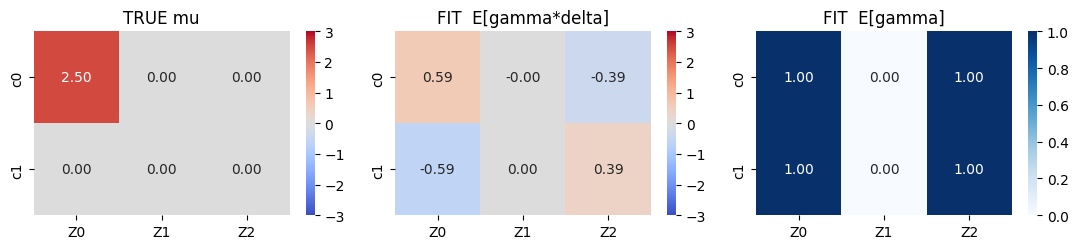

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.6))
sns.heatmap(mu_1, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[0])
axes[0].set_title('TRUE mu')
sns.heatmap(out_c['E_gamma'] * out_c['E_delta'], annot=True, fmt='.2f',
             cmap='coolwarm', center=0, vmin=-3, vmax=3,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[1])
axes[1].set_title('FIT  E[gamma*delta]')
sns.heatmap(out_c['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
             xticklabels=['Z0', 'Z1', 'Z2'], yticklabels=['c0', 'c1'], ax=axes[2])
axes[2].set_title('FIT  E[gamma]')
plt.tight_layout()
plt.show()

## Experiment 2 — Full cohort profiles
C=4, K=3, N=80, sigma=0.8. Distinct mu_c per cohort. Metric: per-cohort corr / MAE
between true mu and E[gamma*delta] rows (expect corr > 0.8, MAE < 1).

Pretraining FA
Fitting model


cohort  row_corr  row_mae
    c0     0.804    1.083
    c1     0.952    1.318
    c2     0.755    0.788
    c3     0.349    1.104


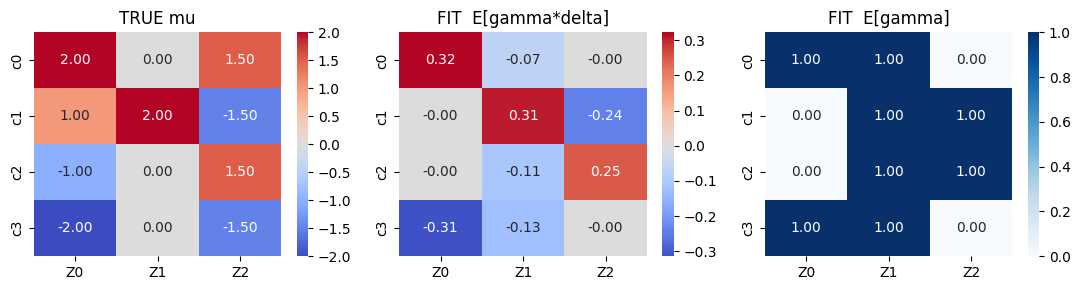

In [6]:
C = 4
K = 3
mu = np.array([
    [ 2.0, 0.0,  1.5],
    [ 1.0, 2.0, -1.5],
    [-1.0, 0.0,  1.5],
    [-2.0, 0.0, -1.5],
])
views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[500] * C, seed=3)
m = fit_cohort(views, K=K, pi=0.5, seed=3)
out = evaluate(m, Z, K=K)

mu_fit = out['E_gamma'] * out['E_delta']
rows = []
for c in range(C):
    corr = float(np.corrcoef(mu[c], mu_fit[c])[0, 1])
    mae = float(np.mean(np.abs(mu[c] - mu_fit[c])))
    rows.append({'cohort': f'c{c}', 'row_corr': corr, 'row_mae': mae})
df_rows = pd.DataFrame(rows)
print(df_rows.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
sns.heatmap(mu, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[0])
axes[0].set_title('TRUE mu')
sns.heatmap(mu_fit, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[1])
axes[1].set_title('FIT  E[gamma*delta]')
sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[2])
axes[2].set_title('FIT  E[gamma]')
plt.tight_layout()
plt.show()

Pretraining FA
Fitting model


cohort  row_corr  row_mae
    c0     1.000    0.836
    c1     0.884    1.159
    c2     0.602    0.829
    c3     0.736    0.937


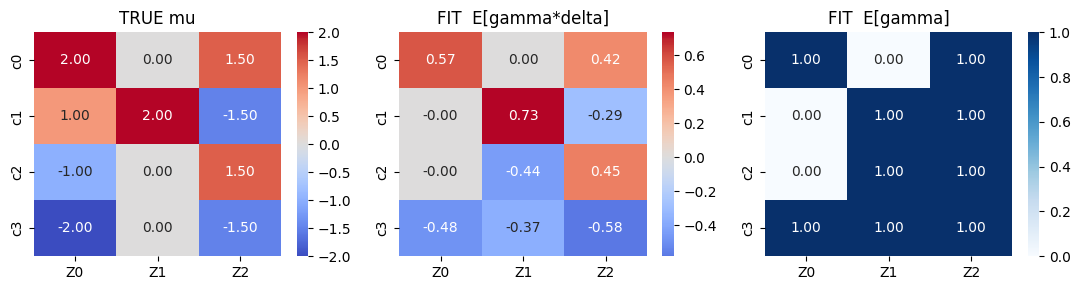

In [7]:
C = 4
K = 3
mu = np.array([
    [ 2.0, 0.0,  1.5],
    [ 1.0, 2.0, -1.5],
    [-1.0, 0.0,  1.5],
    [-2.0, 0.0, -1.5],
])
views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[80] * C, seed=3)
m = fit_cohort(views, K=K, pi=0.3, seed=3)
out = evaluate(m, Z, K=K)

mu_fit = out['E_gamma'] * out['E_delta']
rows = []
for c in range(C):
    corr = float(np.corrcoef(mu[c], mu_fit[c])[0, 1])
    mae = float(np.mean(np.abs(mu[c] - mu_fit[c])))
    rows.append({'cohort': f'c{c}', 'row_corr': corr, 'row_mae': mae})
df_rows = pd.DataFrame(rows)
print(df_rows.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(11, 3))
sns.heatmap(mu, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[0])
axes[0].set_title('TRUE mu')
sns.heatmap(mu_fit, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[1])
axes[1].set_title('FIT  E[gamma*delta]')
sns.heatmap(out['E_gamma'], annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1,
            xticklabels=[f'Z{k}' for k in range(K)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[2])
axes[2].set_title('FIT  E[gamma]')
plt.tight_layout()
plt.show()

## Experiment 3 — Cohort distance structure
C=5, K=3, N=70, sigma=0.8. Metric: correlation between true and fitted pairwise
cohort-distance matrices (expect > 0.9).

Pretraining FA
Fitting model


distance corr (upper triangle) = 0.877


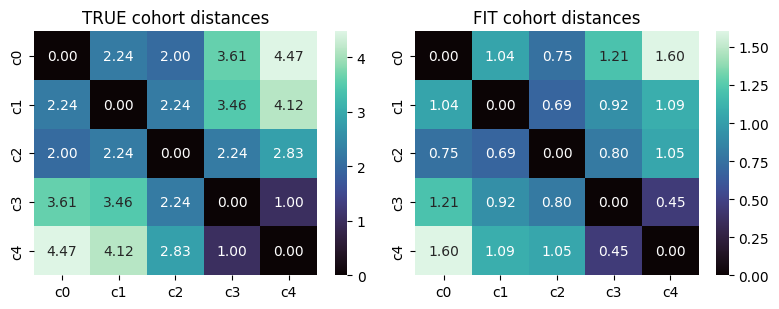

In [8]:
C = 5
K = 3
mu = np.array([
    [ 2.0,  1.0, 0.0],
    [ 1.0,  1.0, 2.0],
    [ 0.0,  1.0, 0.0],
    [-1.0, -1.0, 0.0],
    [-2.0, -1.0, 0.0],
])
views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[70] * C, seed=4)
m = fit_cohort(views, K=K, pi=0.3, seed=4)
out = evaluate(m, Z, K=K)
mu_fit = out['E_gamma'] * out['E_delta']


def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


D_true = cohort_dist(mu)
D_fit = cohort_dist(mu_fit)
tri = np.triu_indices(C, 1)
dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
print(f"distance corr (upper triangle) = {dist_corr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
sns.heatmap(D_true, annot=True, fmt='.2f', cmap='mako',
            xticklabels=[f'c{c}' for c in range(C)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[0])
axes[0].set_title('TRUE cohort distances')
sns.heatmap(D_fit, annot=True, fmt='.2f', cmap='mako',
            xticklabels=[f'c{c}' for c in range(C)],
            yticklabels=[f'c{c}' for c in range(C)], ax=axes[1])
axes[1].set_title('FIT cohort distances')
plt.tight_layout()
plt.show()

## Experiment 4 — Signal scale
Scale base mu by s in {0.5, 1.0, 2.0}. Expect distance recovery to increase with s.

In [9]:
C = 5
K = 3
base_mu = np.array([
    [ 2.0,  1.0, 0.0],
    [ 1.0,  1.0, 2.0],
    [ 0.0,  1.0, 0.0],
    [-1.0, -1.0, 0.0],
    [-2.0, -1.0, 0.0],
])
scales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0]


def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


rows = []
for s in scales:
    mu = s * base_mu
    views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[70] * C, seed=5)
    m = fit_cohort(views, K=K, pi=0.3, seed=5)
    out = evaluate(m, Z, K=K)
    mu_fit = out['E_gamma'] * out['E_delta']
    D_true = cohort_dist(mu)
    D_fit = cohort_dist(mu_fit)
    tri = np.triu_indices(C, 1)
    dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
    rows.append({'scale': s, 'distance_corr': dist_corr})

df_scale = pd.DataFrame(rows)
print(df_scale.round(3).to_string(index=False))

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


...

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


 scale  distance_corr
   0.1          0.788
   0.2          0.355
   0.3          0.569
   0.4          0.847
   0.5          0.924
   0.6          0.905
   0.7          0.898
   0.8          0.854
   0.9          0.817
   1.0          0.792
   1.5          0.735
   2.0          0.730


In [10]:
C = 3
K = 3
base_mu = np.array([
    [ 2.0,  1.0, 0.0],
    [ 1.0,  1.0, 2.0],
    [ 0.0,  1.0, 0.0]
])
scales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0]


def cohort_dist(M):
    diffs = M[:, None, :] - M[None, :, :]
    return np.sqrt(np.sum(diffs ** 2, axis=-1))


rows = []
for s in scales:
    mu = s * base_mu
    views, Z, _ = generate_data(mu, sigma=0.8, n_per_cohort=[70] * C, seed=5)
    m = fit_cohort(views, K=K, pi=0.3, seed=5)
    out = evaluate(m, Z, K=K)
    mu_fit = out['E_gamma'] * out['E_delta']
    D_true = cohort_dist(mu)
    D_fit = cohort_dist(mu_fit)
    tri = np.triu_indices(C, 1)
    dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
    rows.append({'scale': s, 'distance_corr': dist_corr})

df_scale = pd.DataFrame(rows)
print(df_scale.round(3).to_string(index=False))

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


...

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


 scale  distance_corr
   0.1          0.325
   0.2          0.607
   0.3          1.000
   0.4          0.868
   0.5          0.278
   0.6          0.971
   0.7          0.933
   0.8          0.874
   0.9          0.776
   1.0          0.624
   1.5         -0.523
   2.0         -0.371


In [11]:
sigmas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.5, 2.0]

rows = []
for sigma in sigmas:
    views, Z, _ = generate_data(base_mu, sigma=sigma, n_per_cohort=[70] * C, seed=5)
    m = fit_cohort(views, K=K, pi=0.3, seed=5)
    out = evaluate(m, Z, K=K)
    mu_fit = out['E_gamma'] * out['E_delta']
    D_true = cohort_dist(base_mu)
    D_fit = cohort_dist(mu_fit)
    tri = np.triu_indices(C, 1)
    dist_corr = float(np.corrcoef(D_true[tri], D_fit[tri])[0, 1])
    rows.append({'sigma': sigma, 'distance_corr': dist_corr})

df_sigma = pd.DataFrame(rows)
print(df_sigma.round(3).to_string(index=False))

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


...

Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


Pretraining FA
Fitting model


 sigma  distance_corr
   0.1         -0.344
   0.2         -0.252
   0.3         -0.265
   0.4         -0.436
   0.5         -0.292
   0.6         -0.087
   0.7          0.475
   0.8          0.624
   0.9          0.701
   1.0          0.746
   1.5          0.835
   2.0          0.863
